In [11]:
import torch
import torch.nn as nn

# data
x = torch.tensor([[1.0]])
t = torch.tensor([[0.0]])

# model
model = nn.Sequential(
    nn.Linear(1, 1, bias=False),# w1
    nn.ReLU(),
    nn.Linear(1, 1, bias=False),# w2
    nn.ReLU(),
    nn.Linear(1, 1, bias=False) # w3
)

# initialize weights
with torch.no_grad():
    model[0].weight.fill_(2.0)
    model[2].weight.fill_(3.0)
    model[4].weight.fill_(-1.0)

# loss function & grediant optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [12]:
# training loop: 100 epochs
loss_history = []   # 记录每一轮的损失
for epoch in range(100):
    loss = criterion(model(x), t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:3d} | 预测值：{model(x).item():7.4f} | 损失：{loss.item():.4f}")

Epoch   1 | 预测值：-1.2674 | 损失：36.0000
Epoch  11 | 预测值：-0.0084 | 损失：0.0002
Epoch  21 | 预测值：-0.0001 | 损失：0.0000
Epoch  31 | 预测值：-0.0000 | 损失：0.0000
Epoch  41 | 预测值：-0.0000 | 损失：0.0000
Epoch  51 | 预测值：-0.0000 | 损失：0.0000
Epoch  61 | 预测值：-0.0000 | 损失：0.0000
Epoch  71 | 预测值：-0.0000 | 损失：0.0000
Epoch  81 | 预测值：-0.0000 | 损失：0.0000
Epoch  91 | 预测值：-0.0000 | 损失：0.0000


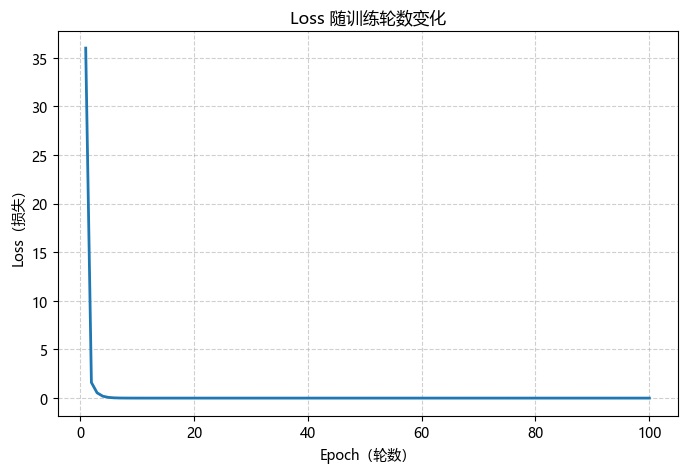

In [13]:
# 可视化 loss function：横轴为轮数，纵轴为损失
import matplotlib.pyplot as plt

# 设置中文字体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='tab:blue', linewidth=2)
plt.xlabel('Epoch（轮数）')
plt.ylabel('Loss（损失）')
plt.title('Loss 随训练轮数变化')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()